# 🧪 Model Lab: Soft Voting Ensemble

이 노트북은 최적화된 로지스틱 회귀, 랜덤 포레스트, XGBoost 모델을 결합한 소프트 보팅(Soft Voting) 앙상블의 성능을 평가합니다.

### 🧪 실험 설정
- **구성 모델:** Logistic Regression, Random Forest, XGBoost
- **결합 방식:** Soft Voting (확률 평균)
- **데이터 분할:** Train(70%) / Val(15%) / Test(15%)
- **평가 지표:** Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [10]:
# 1. 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows용 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='Malgun Gothic')

In [2]:
# 2. 데이터 준비
df = pd.read_csv("../data/processed/selected_features_data.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Date', 'ticker'])

exclude = ['Date', 'ticker', 'target', 'next_return']
features = [c for c in df.columns if c not in exclude]
X = df[features]
y = df['target']

# 70/15/15 시계열 분할
n = len(df)
tr_idx, val_idx = int(n*0.7), int(n*0.85)

X_train, y_train = X.iloc[:tr_idx], y.iloc[:tr_idx]
X_val, y_val = X.iloc[tr_idx:val_idx], y.iloc[tr_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")

Train set: (1024, 25), Val set: (220, 25), Test set: (220, 25)


In [3]:
# 3. 개별 최적 모델 정의 및 소프트 보팅 구성

# 1) Logistic Regression (Best: ElasticNet, C=0.001, balanced)
lr_best = LogisticRegression(
    C=0.001, 
    class_weight='balanced', 
    l1_ratio=0.5, 
    penalty='elasticnet', 
    solver='saga', 
    max_iter=10000, 
    random_state=42
)

# 2) Random Forest (Best: max_depth=3, min_samples_leaf=10)
rf_best = RandomForestClassifier(
    n_estimators=200, 
    max_depth=3, 
    min_samples_leaf=10, 
    min_samples_split=20, 
    max_features='sqrt', 
    random_state=42
)

# 3) XGBoost (Best: learning_rate=0.01, max_depth=2, reg_alpha=1)
xgb_best = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.01, 
    max_depth=2, 
    subsample=0.7, 
    colsample_bytree=0.7, 
    reg_alpha=1, 
    reg_lambda=1, 
    eval_metric='logloss', 
    random_state=42
)

# 소프트 보팅 앙상블 구성
voting_clf = VotingClassifier(
    estimators=[
        ('lr', lr_best), 
        ('rf', rf_best), 
        ('xgb', xgb_best)
    ],
    voting='soft'
)

print("--- 소프트 보팅 앙상블 학습 중 ---")
voting_clf.fit(X_train, y_train)

def get_metrics(model, X_set, y_set, label):
    preds = model.predict(X_set)
    probs = model.predict_proba(X_set)[:, 1]
    return {
        'Set': label,
        'Accuracy': accuracy_score(y_set, preds),
        'Precision': precision_score(y_set, preds),
        'Recall': recall_score(y_set, preds),
        'F1': f1_score(y_set, preds),
        'AUC': roc_auc_score(y_set, probs)
    }

results = pd.DataFrame([
    get_metrics(voting_clf, X_train, y_train, 'Train'),
    get_metrics(voting_clf, X_val, y_val, 'Val'),
    get_metrics(voting_clf, X_test, y_test, 'Test')
])

print("\n--- Soft Voting Ensemble Performance ---")
display(results)

--- 소프트 보팅 앙상블 학습 중 ---

--- Soft Voting Ensemble Performance ---


,Set,Accuracy,Precision,Recall,F1,AUC
0,Train,0.649414,0.614014,0.938294,0.742283,0.744754
1,Val,0.522727,0.527027,0.690265,0.597701,0.522207
2,Test,0.531818,0.543478,0.652174,0.592885,0.495652


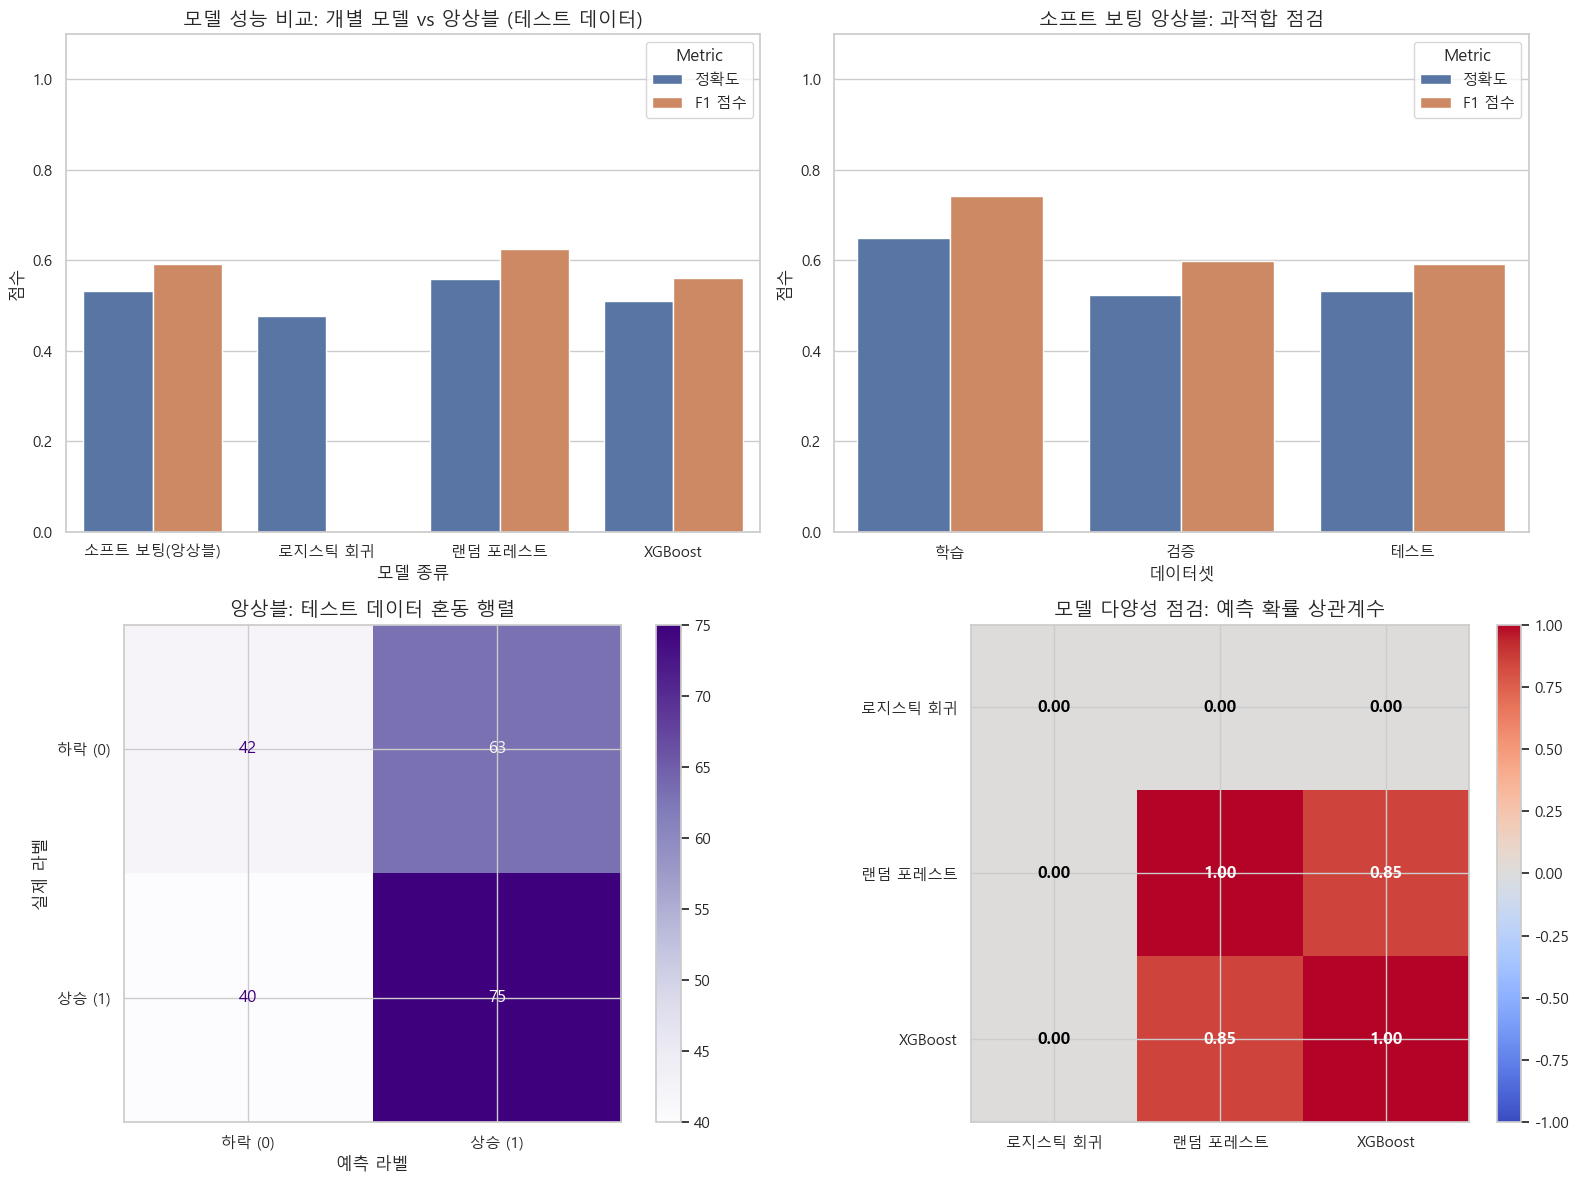


--- [모델 간 상관계수 수치 데이터] ---


,로지스틱 회귀,랜덤 포레스트,XGBoost
로지스틱 회귀,0.0,0.0000,0.0000
랜덤 포레스트,0.0,1.0000,0.8456
XGBoost,0.0,0.8456,1.0000


In [16]:
# 4. 결과 시각화 및 모델 기여도 분석 (한글화)

# 한글 라벨 및 모델명 매핑
name_map = {
    'Ensemble': '소프트 보팅(앙상블)',
    'Logistic Regression': '로지스틱 회귀',
    'Random Forest': '랜덤 포레스트',
    'XGBoost': 'XGBoost'
}
metric_map = {
    'Accuracy': '정확도',
    'F1': 'F1 점수'
}

# 1) 개별 모델 vs 앙상블 성능 비교 (테스트 데이터)
comparison_data = []

# 앙상블 모델 추가
ensemble_metrics = get_metrics(voting_clf, X_test, y_test, name_map['Ensemble'])
comparison_data.append(ensemble_metrics)

# 개별 모델 추가
for name, model in voting_clf.named_estimators_.items():
    model_id = {'lr': 'Logistic Regression', 'rf': 'Random Forest', 'xgb': 'XGBoost'}[name]
    metrics = get_metrics(model, X_test, y_test, name_map[model_id])
    comparison_data.append(metrics)

comp_df = pd.DataFrame(comparison_data)

# 시각화 레이아웃 설정 (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1,1) 정확도 & F1 비교 (개별 모델 vs 앙상블)
melted_comp = comp_df.melt(id_vars='Set', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')
melted_comp['Metric'] = melted_comp['Metric'].map(metric_map)

sns.barplot(data=melted_comp, x='Set', y='Score', hue='Metric', ax=axes[0, 0])
axes[0, 0].set_title("모델 성능 비교: 개별 모델 vs 앙상블 (테스트 데이터)", fontsize=14)
axes[0, 0].set_ylim(0, 1.1)
axes[0, 0].set_xlabel("모델 종류")
axes[0, 0].set_ylabel("점수")

# (1,2) 앙상블 성능 추이 (과적합 점검)
results_ko = results.copy()
results_ko['Set'] = results_ko['Set'].map({'Train': '학습', 'Val': '검증', 'Test': '테스트'})
melted_results = results_ko.melt(id_vars='Set', value_vars=['Accuracy', 'F1'], var_name='Metric', value_name='Score')
melted_results['Metric'] = melted_results['Metric'].map(metric_map)

sns.barplot(data=melted_results, x='Set', y='Score', hue='Metric', ax=axes[0, 1])
axes[0, 1].set_title("소프트 보팅 앙상블: 과적합 점검", fontsize=14)
axes[0, 1].set_ylim(0, 1.1)
axes[0, 1].set_xlabel("데이터셋")
axes[0, 1].set_ylabel("점수")

# (2,1) 혼동 행렬 (앙상블)
y_pred = voting_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['하락 (0)', '상승 (1)'])
disp.plot(ax=axes[1, 0], cmap='Purples', values_format='d')
axes[1, 0].set_title('앙상블: 테스트 데이터 혼동 행렬', fontsize=14)
axes[1, 0].set_xlabel("예측 라벨")
axes[1, 0].set_ylabel("실제 라벨")

# (2,2) 개별 모델 간 예측 상관관계 (다양성 점검)
test_probs = pd.DataFrame({
    '로지스틱 회귀': voting_clf.named_estimators_['lr'].predict_proba(X_test)[:, 1],
    '랜덤 포레스트': voting_clf.named_estimators_['rf'].predict_proba(X_test)[:, 1],
    'XGBoost': voting_clf.named_estimators_['xgb'].predict_proba(X_test)[:, 1]
})

# 상관계수 계산 및 NaN 처리
corr_matrix = test_probs.corr().fillna(0)
labels = corr_matrix.columns

# ConfusionMatrixDisplay 스타일로 직접 그리기
im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 1].set_title("모델 다양성 점검: 예측 확률 상관계수", fontsize=14)

# 축 설정
axes[1, 1].set_xticks(np.arange(len(labels)))
axes[1, 1].set_yticks(np.arange(len(labels)))
axes[1, 1].set_xticklabels(labels)
axes[1, 1].set_yticklabels(labels)

# 각 칸에 수치 값 직접 써넣기 (ConfusionMatrixDisplay 방식)
thresh = corr_matrix.values.max() / 2.
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        axes[1, 1].text(j, i, f"{val:.2f}",
                       ha="center", va="center",
                       color="white" if abs(val) > 0.5 else "black",
                       fontsize=12, weight='bold')

fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# 수치가 안 보일 경우를 대비해 텍스트로도 출력
print("\n--- [모델 간 상관계수 수치 데이터] ---")
display(corr_matrix.round(4))

# LR 진단 메시지
lr_std = test_probs['로지스틱 회귀'].std()
if lr_std == 0:
    print("\n[참고] '로지스틱 회귀'의 예측값이 모든 데이터에서 동일합니다. (상관계수 계산 불가)")
    print("모델이 너무 단순화되어 다양성에 기여하지 못하고 있습니다.")
